In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Define the path to the uploaded Tokyo Airbnb dataset in your Drive
file_path = '/content/drive/MyDrive/HIT_DataScience_HW1/listings.csv'

# Load the compressed data into a pandas DataFrame
# The compression='gzip' argument tells pandas to decompress it on the fly
tokyo_airbnb_df = pd.read_csv(file_path)

# --- Task Section 3.2: Data Structure ---

# Display the number of rows and columns
rows, columns = tokyo_airbnb_df.shape
print(f"The dataset contains {rows} rows and {columns} columns.\n")

# Display the first 3 rows to verify the column names make sense
tokyo_airbnb_df.head(3)

The dataset contains 34419 rows and 90 columns.



,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,33121264,https://www.airbnb.com/rooms/33121264,20260630053204,2026-06-30,city scrape,新宿20m.新築build by Muji 駅徒歩8分Walmart 無料駐車四季bbq可,NaN,NaN,https://a0.muscache.com/pictures/99b5b45d-7f27...,116761693,...,4.84,4.59,4.56,M130014385,NaN,5,5,0,0,2.65
1,1707828556158854666,https://www.airbnb.com/rooms/1707828556158854666,20260630053204,2026-06-30,city scrape,駅徒歩3分｜ロフト付きコンパクトルーム｜国分寺10分｜中長期滞在歓迎（２階）,Relax and stretch your wings in a restful stay...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,474979321,...,NaN,NaN,NaN,M130063043,NaN,9,8,1,0,NaN
2,1428729810381657893,https://www.airbnb.com/rooms/1428729810381657893,20260630053204,2026-07-02,city scrape,ダブルルーム黄色 共有バスルーム,The room has a yellow tone.<br />You can see t...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,697092506,...,NaN,NaN,NaN,Hotels and Inns Business Act | 墨田区保健所 | 6墨福衛生環...,NaN,8,0,8,0,NaN


2.2 Data Source Description

Data Source: The data was obtained from "Inside Airbnb" (insideairbnb.com), an independent, non-commercial open-source data project.

Purpose of Collection: The primary purpose of the Inside Airbnb project is to provide data that empowers communities to understand, decide, and control the effects of short-term rentals on their residential neighborhoods and housing markets. Originally, the data is generated by Airbnb for operational and commercial purposes (facilitating bookings).

Collecting Entity: The data is scraped and compiled by the "Inside Airbnb" project team (founded by Murray Cox) directly from publicly available information on the official Airbnb website.

Domain Knowledge Connection: My familiarity with Tokyo's layout, transportation systems, and distinct neighborhoods from a five-week trip through Tokyo and Osaka provides a practical lens for analyzing this dataset. This firsthand experience helps in understanding geographic price disparities, the appeal of certain wards (like Shibuya or Shinjuku) for tourists, and potential biases in how listings are marketed versus their actual residential reality.

### 3.3 Data Quality Analysis

### 3. Data Meta-Analysis

**3.1 File Analysis**
* **File Format:** Compressed CSV (`.csv.gz`).
* **File Size:** 110MB
* **Creation Date:** 30.6.26
* **Purpose of the Data:** The original data is operational (facilitating property bookings and transactions on Airbnb). However, this specific compilation by *Inside Airbnb* was collected for research purposes—to analyze the impact of short-term rentals on housing markets.

**3.2 Data Structure**
* **Rows and Columns:** Based on the `.shape` output, the dataset contains 34419 rows and 90 columns.
* **Column Names & Insights:** The column names are descriptive (e.g., `room_type`, `price`, `minimum_nights`). However, their structure suggests necessary cleaning steps. For instance, the `price` column likely contains currency symbols (e.g., '$'), meaning it will be initially parsed as a string (`object`) rather than a numeric value.
* **Data Types:** The data is a mix of `int64`, `float64`, and `object`. Many time-related variables (like `host_since` or `last_review`) are parsed as strings (`object`) and will require explicit conversion to `datetime` objects before performing time-series analysis.
* **Data Validation Considerations:**
    * **Completeness:** Identify columns with a high percentage of missing values (NaNs) that might require imputation or removal.
    * **Uniqueness:** Check for duplicate rows, especially based on primary identifiers like `id` or `listing_url`, to ensure each entry is distinct.
    * **Consistency:** Verify that categorical variables (e.g., `room_type`) contain expected values and that numerical values (e.g., `price`, `minimum_nights`) fall within reasonable ranges.
    * **Accuracy:** Although harder to validate without external data, cross-referencing related columns (e.g., `review_scores_rating` should align with individual review scores if available) can expose inconsistencies.
    * **Data Types:** Confirm that once converted, `datetime` objects are valid dates and numerical columns are indeed numeric.

**Discussion: Operational vs. Research & Potential Biases**
While the data is analyzed for research, its operational origin introduces several inherent biases:
* **Snapshot/Availability Bias:** The web scraper only captures listings visible on the specific day it was run. Fully booked, hidden, or temporarily deactivated listings are excluded from the dataset.
* **Geographic and Tourist Bias:** Neighborhoods with high tourist demand and foot traffic (such as Shibuya or Shinjuku) are heavily overrepresented in the dataset. This skews average prices and availability, reflecting the "tourist experience" rather than the standard residential reality of Tokyo.
* **Review Bias:** Listings in central, highly sought-after wards accumulate reviews much faster, potentially skewing perceived popularity and rendering newer listings in peripheral wards seemingly less attractive.

### 4. Data Quality and Completeness

**4.1 Missing Data**
* **Extent:** There are 47 columns with missing values. The missing data is distributed in two main groups: columns with 100% missing values (e.g., `neighborhood_overview`, `host_neighbourhood`), and columns with about 12-13% missing values (e.g., `review_scores_rating`, `first_review`).
* **Pattern:** The pattern is highly **structured/systematic**, not random. The 100% missing columns are likely due to Airbnb's API restrictions preventing the scraper from accessing specific host information. The 12-13% missing pattern perfectly correlates with listings that are brand new or simply haven't received any guests yet, hence they have no reviews.
* **Inference:** We learn that the scraping process has technical limitations, and that roughly an eighth of the Tokyo market consists of unreviewed/new properties.
* **Handling Strategy:** I will completely drop the columns with 100% missing data, as they provide no value. For the review columns, I will fill the numerical NaN values with `0` (indicating no score), or keep them as NaN depending on whether we analyze purely reviewed listings.

**4.2 Duplicates**
* **Full Duplicates:** The analysis confirmed there are exactly `0` fully duplicated rows.
* **Partial Duplicates:** While full row duplicates don't exist, partial duplicates might occur if a host lists the exact same physical apartment under two different listing IDs to bypass calendar restrictions or boost visibility.
* **Inference & Action:** The lack of full duplicates indicates a clean scraping process for unique IDs. No rows need to be dropped at this stage based on full duplication.

**4.3 Suspicious Values**
* **Impossible/Unlikely Values:** The `price` column shows a minimum of 1,514 JPY and an extreme maximum of 5,449,800 JPY (over $35,000 USD per night). Additionally, 2,058 non-numeric values were found and coerced to NaN.
* **Inferences:** The minimum value (~1,500 JPY) is entirely logical for Tokyo, reflecting budget accommodations like capsule hotels or net cafes. However, the 5.4 million JPY maximum is highly suspicious. It is a classic "placeholder value" – hosts often set mathematically absurd prices to temporarily prevent bookings when they are away or renovating, without deleting their listing to maintain their search ranking.
* **Handling Strategy:** We must apply a filter to remove extreme outliers in the price column before proceeding to Univariate Analysis.

**4.4 Cardinality**
* **Zero Variance (Single Value):** Several columns exhibit zero variance (only one unique value), such as `scrape_id`, `calendar_updated`, and `has_availability`.
* **High Cardinality:** Columns like `listing_url`, `name`, and `id` have nearly as many unique values as there are rows.
* **Action:** Columns with a single value are useless for statistical analysis or machine learning as they contain no information. They will be dropped from the DataFrame to reduce noise and memory usage.

### 4.5 Data Cleaning Implementation

In [ ]:
# Identify columns with 100% missing values
columns_100_percent_missing = missing_info[missing_info['Missing Percentage'] == 100].index.tolist()

# Identify columns with a single unique value (excluding those that are also 100% missing and already handled)
single_value_cols = [col for col in single_unique_value_cols if col not in columns_100_percent_missing]

# Combine all columns to drop
columns_to_drop = list(set(columns_100_percent_missing + single_value_cols))

# Drop the identified columns
tokyo_airbnb_df_cleaned = tokyo_airbnb_df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
print(f"New DataFrame shape: {tokyo_airbnb_df_cleaned.shape}")

Dropped 14 columns: ['neighborhood_overview', 'neighbourhood_group_cleansed', 'host_acceptance_rate', 'host_since', 'host_verifications', 'host_neighbourhood', 'scrape_id', 'instant_bookable', 'calendar_updated', 'host_total_listings_count', 'neighbourhood', 'host_response_time', 'host_thumbnail_url', 'host_response_rate']
New DataFrame shape: (34419, 76)


In [ ]:
# Handle missing values in review score columns by filling with 0
# These columns were identified as having ~12-13% missing values, likely for unreviewed listings.
review_score_columns = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month', 'first_review', 'last_review'
]

for col in review_score_columns:
    if col in tokyo_airbnb_df_cleaned.columns:
        if tokyo_airbnb_df_cleaned[col].dtype == 'object': # For 'first_review' and 'last_review'
            tokyo_airbnb_df_cleaned[col] = tokyo_airbnb_df_cleaned[col].fillna('No Reviews')
        else: # For numerical review scores
            tokyo_airbnb_df_cleaned[col] = tokyo_airbnb_df_cleaned[col].fillna(0)

print("Missing values in review-related columns filled.")

Missing values in review-related columns filled.


In [ ]:
# Clean the 'price' column again in the cleaned DataFrame to ensure it's numeric for filtering
# The temporary 'price_cleaned' column was dropped previously, so re-cleaning is necessary.
cleaned_price_series = tokyo_airbnb_df_cleaned['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
tokyo_airbnb_df_cleaned['price_numeric'] = pd.to_numeric(cleaned_price_series, errors='coerce')

# Drop rows where price_numeric became NaN during conversion (i.e., truly non-numeric prices)
tokyo_airbnb_df_cleaned.dropna(subset=['price_numeric'], inplace=True)

# Define reasonable price bounds (e.g., between 1000 JPY and 100,000 JPY)
# The markdown noted a max of 5.4M JPY was suspicious; a reasonable upper bound for daily price is needed.
# Let's set a realistic upper bound, e.g., 100,000 JPY (~700 USD) for a high-end daily rental.
lower_bound = 1000.0  # JPY
upper_bound = 100000.0 # JPY

# Filter out price outliers
initial_rows = tokyo_airbnb_df_cleaned.shape[0]
tokyo_airbnb_df_cleaned = tokyo_airbnb_df_cleaned[
    (tokyo_airbnb_df_cleaned['price_numeric'] >= lower_bound) &
    (tokyo_airbnb_df_cleaned['price_numeric'] <= upper_bound)
]

# Replace the original 'price' column with the cleaned numeric one, or keep a new column.
# For now, let's keep 'price_numeric' and drop the original 'price' if it's still 'object'.
if 'price' in tokyo_airbnb_df_cleaned.columns and tokyo_airbnb_df_cleaned['price'].dtype == 'object':
    tokyo_airbnb_df_cleaned = tokyo_airbnb_df_cleaned.drop(columns=['price'])

# Rename the cleaned price column to 'price' for consistency
tokyo_airbnb_df_cleaned.rename(columns={'price_numeric': 'price'}, inplace=True)

rows_after_price_filter = tokyo_airbnb_df_cleaned.shape[0]
print(f"Removed {initial_rows - rows_after_price_filter} rows due to price outliers.")
print(f"Current DataFrame shape after price filtering: {tokyo_airbnb_df_cleaned.shape}")

Removed 902 rows due to price outliers.
Current DataFrame shape after price filtering: (31459, 76)


In [ ]:
# Display the first few rows of the cleaned DataFrame and its info to confirm changes
display(tokyo_airbnb_df_cleaned.head())
print("\nInfo of cleaned DataFrame:")
tokyo_airbnb_df_cleaned.info()

,id,listing_url,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,33121264,https://www.airbnb.com/rooms/33121264,2026-06-30,city scrape,新宿20m.新築build by Muji 駅徒歩8分Walmart 無料駐車四季bbq可,NaN,https://a0.muscache.com/pictures/99b5b45d-7f27...,116761693,https://www.airbnb.com/users/show/116761693,1468196457784084703,...,4.84,4.59,4.56,M130014385,5,5,0,0,2.65,49000.0
1,1707828556158854666,https://www.airbnb.com/rooms/1707828556158854666,2026-06-30,city scrape,駅徒歩3分｜ロフト付きコンパクトルーム｜国分寺10分｜中長期滞在歓迎（２階）,Relax and stretch your wings in a restful stay...,https://a0.muscache.com/pictures/hosting/Hosti...,474979321,https://www.airbnb.com/users/show/474979321,1463789616230750592,...,0.00,0.00,0.00,M130063043,9,8,1,0,0.00,9647.5
2,1428729810381657893,https://www.airbnb.com/rooms/1428729810381657893,2026-07-02,city scrape,ダブルルーム黄色 共有バスルーム,The room has a yellow tone.<br />You can see t...,https://a0.muscache.com/pictures/miso/Hosting-...,697092506,https://www.airbnb.com/users/show/697092506,1470735923242995728,...,0.00,0.00,0.00,Hotels and Inns Business Act | 墨田区保健所 | 6墨福衛生環...,8,0,8,0,0.00,5500.0
3,1671729464506095090,https://www.airbnb.com/rooms/1671729464506095090,2026-07-01,city scrape,新宿/西新宿5丁目駅徒歩3分/新宿駅まで3分/Switch/pocketWi-Fi/NET①,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,274793900,https://www.airbnb.com/users/show/274793900,1463361187181720250,...,0.00,0.00,0.00,M130050822,33,30,3,0,0.00,19100.0
4,1604694972630799987,https://www.airbnb.com/rooms/1604694972630799987,2026-07-01,city scrape,烟雨轩105 4号床（仅限女性预定）,Take it easy at this unique and tranquil getaway.,https://a0.muscache.com/pictures/hosting/Hosti...,572381822,https://www.airbnb.com/users/show/572381822,1470551497115897590,...,4.33,4.67,4.83,M130039910,8,0,1,7,1.36,4416.0



Info of cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 31459 entries, 0 to 34418
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            31459 non-null  int64  
 1   listing_url                                   31459 non-null  object 
 2   last_scraped                                  31459 non-null  object 
 3   source                                        31459 non-null  object 
 4   name                                          31459 non-null  object 
 5   description                                   30715 non-null  object 
 6   picture_url                                   31459 non-null  object 
 7   host_id                                       31459 non-null  int64  
 8   host_url                                      31459 non-null  object 
 9   host_profile_id                       

### 5. Univariate Analysis

Univariate analysis helps us understand the characteristics of individual variables in our dataset. We'll examine numerical statistics, detect outliers, and analyze categorical distributions.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from statsmodels.robust.scale import mad

def analyze_numerical_column(df, column_name):
    """
    Calculates and prints key numerical statistics for a specified column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the numerical column to analyze.
    """
    print(f"\n--- Numerical Analysis for '{column_name}' ---")

    # Ensure the column is numeric before proceeding
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Warning: Column '{column_name}' is not numeric. Attempting conversion.")
        # Try cleaning again just in case, but assume it's already done from previous steps.
        cleaned_series = df[column_name].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[column_name] = pd.to_numeric(cleaned_series, errors='coerce')
        df.dropna(subset=[column_name], inplace=True) # Drop NaNs introduced by coercion
        print(f"Column '{column_name}' converted to numeric and NaNs dropped. New count: {len(df)}")

    # Basic statistics
    mean_val = df[column_name].mean()
    median_val = df[column_name].median()
    std_dev = df[column_name].std()
    min_val = df[column_name].min()
    max_val = df[column_name].max()

    # Quantiles and IQR
    q1 = df[column_name].quantile(0.25)
    q2 = df[column_name].quantile(0.50) # Same as median
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1

    # Mean Absolute Deviation (MAD)
    mad_val = mad(df[column_name].dropna()) # mad function requires no NaNs

    # Skewness
    skewness = skew(df[column_name].dropna()) # skew function requires no NaNs

    print(f"Mean: {mean_val:,.2f}")
    print(f"Median: {median_val:,.2f}")
    print(f"Standard Deviation: {std_dev:,.2f}")
    print(f"Min: {min_val:,.2f}")
    print(f"Max: {max_val:,.2f}")
    print(f"25th Percentile (Q1): {q1:,.2f}")
    print(f"50th Percentile (Q2/Median): {q2:,.2f}")
    print(f"75th Percentile (Q3): {q3:,.2f}")
    print(f"IQR (Q3 - Q1): {iqr:,.2f}")
    print(f"Mean Absolute Deviation (MAD): {mad_val:,.2f}")
    print(f"Skewness: {skewness:.4f}")

def detect_outliers(series, method, threshold=None):
    """
    Detects outliers in a numerical series using specified methods.

    Args:
        series (pd.Series): The numerical series to analyze.
        method (str): The outlier detection method ('z_score', 'iqr', 'mad_z_score').
        threshold (float): The threshold for Z-score or Modified Z-score methods.

    Returns:
        int: The number of detected outliers.
    """
    series = series.dropna() # Ensure no NaNs
    num_outliers = 0

    if method == 'z_score':
        if threshold is None: threshold = 3
        mean = series.mean()
        std = series.std()
        if std == 0: # Handle cases with no variance
            num_outliers = 0
        else:
            z_scores = np.abs((series - mean) / std)
            num_outliers = (z_scores > threshold).sum()
        print(f"  - Z-Score (threshold={threshold}): {num_outliers} outliers")

    elif method == 'iqr':
        if threshold is None: threshold = 1.5 # Default for IQR
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        num_outliers = ((series < lower_bound) | (series > upper_bound)).sum()
        print(f"  - IQR Method ({threshold} * IQR): {num_outliers} outliers")

    elif method == 'mad_z_score':
        if threshold is None: threshold = 3.5 # Common threshold for Modified Z-score
        median_val = series.median()
        mad_val = mad(series)
        if mad_val == 0: # Handle cases with no variance (all values are the same)
            num_outliers = 0
        else:
            # Modified Z-score: 0.6745 * (xi - median) / MAD
            modified_z_scores = 0.6745 * np.abs(series - median_val) / mad_val
            num_outliers = (modified_z_scores > threshold).sum()
        print(f"  - MAD Method (Modified Z-score threshold={threshold}): {num_outliers} outliers")

    return num_outliers

def analyze_categorical_column(df, column_name, top_k=3, percentage_threshold=80):
    """
    Analyzes a categorical column for frequencies, percentages, top categories, and rare categories.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the categorical column to analyze.
        top_k (int): The number of top categories to display.
        percentage_threshold (int): The percentage of data to be covered by minimum categories.
    """
    print(f"\n--- Categorical Analysis for '{column_name}' ---")

    # Calculate value counts and percentages
    value_counts = df[column_name].value_counts()
    value_percentages = df[column_name].value_counts(normalize=True) * 100

    # Display frequencies and percentages
    print("Category Frequencies and Percentages:")
    display(pd.DataFrame({'Count': value_counts, 'Percentage': value_percentages}).head(10))
    print("...")

    # Top K categories
    top_categories = value_percentages.head(top_k)
    print(f"\nTop {top_k} Categories:")
    for category, percent in top_categories.items():
        print(f"  - {category}: {percent:.2f}%")
    print(f"Total percentage of Top {top_k} categories: {top_categories.sum():.2f}%")

    # Minimum categories needed to represent P% of data
    cumulative_percentage = value_percentages.cumsum()
    min_categories_count = (cumulative_percentage < percentage_threshold).sum() + 1
    print(f"\nMinimum number of categories needed to represent {percentage_threshold}% of data: {min_categories_count}")
    print(f"These categories are: {value_percentages.head(min_categories_count).index.tolist()}")

    # Rare categories (less than 1% of data)
    rare_categories = value_percentages[value_percentages < 1]
    print(f"\nRare Categories (less than 1% of data): {len(rare_categories)} found")
    if not rare_categories.empty:
        display(rare_categories.head())


#### Performing Univariate Analysis on `price`

In [ ]:
# Analyze numerical column: 'price'
analyze_numerical_column(tokyo_airbnb_df_cleaned, 'price')


--- Numerical Analysis for 'price' ---
Mean: 23,580.75
Median: 19,189.33
Standard Deviation: 15,646.53
Min: 1,514.00
Max: 100,000.00
25th Percentile (Q1): 13,279.00
50th Percentile (Q2/Median): 19,189.33
75th Percentile (Q3): 29,100.00
IQR (Q3 - Q1): 15,821.00
Mean Absolute Deviation (MAD): 10,658.92
Skewness: 1.7985


#### Outlier Detection on `price`

In [ ]:
print("\n--- Outlier Detection for 'price' ---")
# Z-Score Method
detect_outliers(tokyo_airbnb_df_cleaned['price'], method='z_score', threshold=3)

# IQR Method
detect_outliers(tokyo_airbnb_df_cleaned['price'], method='iqr', threshold=1.5)

# MAD Method
detect_outliers(tokyo_airbnb_df_cleaned['price'], method='mad_z_score', threshold=3.5)


--- Outlier Detection for 'price' ---
  - Z-Score (threshold=3): 709 outliers
  - IQR Method (1.5 * IQR): 1820 outliers
  - MAD Method (Modified Z-score threshold=3.5): 586 outliers


np.int64(586)

#### Performing Univariate Analysis on Categorical Columns

In [ ]:
# Analyze categorical column: 'room_type'
analyze_categorical_column(tokyo_airbnb_df_cleaned, 'room_type', top_k=3, percentage_threshold=80)


--- Categorical Analysis for 'room_type' ---
Category Frequencies and Percentages:


,Count,Percentage
room_type,,
Entire home/apt,26433,84.023650
Private room,4605,14.638100
Shared room,311,0.988588
Hotel room,110,0.349661


...

Top 3 Categories:
  - Entire home/apt: 84.02%
  - Private room: 14.64%
  - Shared room: 0.99%
Total percentage of Top 3 categories: 99.65%

Minimum number of categories needed to represent 80% of data: 1
These categories are: ['Entire home/apt']

Rare Categories (less than 1% of data): 2 found


,proportion
room_type,
Shared room,0.988588
Hotel room,0.349661


In [ ]:
# Analyze categorical column: 'neighbourhood_cleansed'
analyze_categorical_column(tokyo_airbnb_df_cleaned, 'neighbourhood_cleansed', top_k=3, percentage_threshold=80)


--- Categorical Analysis for 'neighbourhood_cleansed' ---
Category Frequencies and Percentages:


,Count,Percentage
neighbourhood_cleansed,,
Shinjuku Ku,5166,16.421374
Sumida Ku,4694,14.921008
Taito Ku,3308,10.515274
Toshima Ku,2931,9.316889
Shibuya Ku,2186,6.948727
Ota Ku,1440,4.577386
Minato Ku,1372,4.361232
Katsushika Ku,1119,3.557011
Nakano Ku,1056,3.356750


...

Top 3 Categories:
  - Shinjuku Ku: 16.42%
  - Sumida Ku: 14.92%
  - Taito Ku: 10.52%
Total percentage of Top 3 categories: 41.86%

Minimum number of categories needed to represent 80% of data: 11
These categories are: ['Shinjuku Ku', 'Sumida Ku', 'Taito Ku', 'Toshima Ku', 'Shibuya Ku', 'Ota Ku', 'Minato Ku', 'Katsushika Ku', 'Nakano Ku', 'Kita Ku', 'Setagaya Ku']

Rare Categories (less than 1% of data): 32 found


,proportion
neighbourhood_cleansed,
Chiyoda Ku,0.877332
Arakawa Ku,0.794685
Nerima Ku,0.505420
Meguro Ku,0.451381
Musashino Shi,0.184367


In [ ]:
print('--- Missing Values Analysis ---')
# Calculate the count of missing values for each column
missing_counts = tokyo_airbnb_df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentages = (tokyo_airbnb_df.isnull().sum() / len(tokyo_airbnb_df)) * 100

# Create a DataFrame to display missing values information
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

# Filter to show only columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Display the missing values information
print('Columns with Missing Values:')
display(missing_info)

print(f"\nTotal columns with missing values: {len(missing_info)}")

--- Missing Values Analysis ---
Columns with Missing Values:


,Missing Count,Missing Percentage
neighborhood_overview,34419,100.000000
host_since,34419,100.000000
host_neighbourhood,34419,100.000000
host_thumbnail_url,34419,100.000000
host_acceptance_rate,34419,100.000000
host_response_rate,34419,100.000000
host_response_time,34419,100.000000
host_verifications,34419,100.000000
host_total_listings_count,34419,100.000000
neighbourhood,34419,100.000000



Total columns with missing values: 47


In [ ]:
print('\n--- Duplicate Rows Analysis ---')
# Calculate the number of fully duplicated rows
duplicate_rows = tokyo_airbnb_df.duplicated().sum()

# Display the total number of duplicated rows
print(f"Total number of fully duplicated rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Consider removing these duplicates to avoid skewed analysis.")
else:
    print("No fully duplicated rows found. The dataset is unique at a row level.")


--- Duplicate Rows Analysis ---
Total number of fully duplicated rows: 0
No fully duplicated rows found. The dataset is unique at a row level.


In [ ]:
print('\n--- Suspicious Values Check for \'price\' Column ---')
# The 'price' column is often loaded as an object due to currency symbols (e.g., '$', ',').
# First, clean the 'price' column by removing non-numeric characters and converting to numeric.
# We use errors='coerce' to turn any values that cannot be converted into NaN.
cleaned_price = tokyo_airbnb_df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
tokyo_airbnb_df['price_cleaned'] = pd.to_numeric(cleaned_price, errors='coerce')

# Check for any NaNs introduced during cleaning (values that couldn't be converted)
invalid_prices = tokyo_airbnb_df['price_cleaned'].isnull().sum()
if invalid_prices > 0:
    print(f"Warning: {invalid_prices} non-numeric values found and coerced to NaN in 'price' column.")

# Calculate the minimum and maximum values for the cleaned 'price' column
min_price = tokyo_airbnb_df['price_cleaned'].min()
max_price = tokyo_airbnb_df['price_cleaned'].max()

# Display the min and max price
print(f"Minimum price: {min_price}")
print(f"Maximum price: {max_price}")

# Provide context for suspicious values (e.g., extremely low or high prices)
if min_price == 0:
    print("Suspicion: A minimum price of 0 might indicate free listings, data entry errors, or promotional offers. Further investigation may be needed.")
if max_price > 100000: # Example threshold for very high prices
    print("Suspicion: An extremely high maximum price might indicate luxury listings, data entry errors, or unusual long-term rental pricing. Further investigation may be needed.")

# Drop the temporary cleaned price column
tokyo_airbnb_df = tokyo_airbnb_df.drop(columns=['price_cleaned'])


--- Suspicious Values Check for 'price' Column ---
Minimum price: 1514.0
Maximum price: 5449800.0
Suspicion: An extremely high maximum price might indicate luxury listings, data entry errors, or unusual long-term rental pricing. Further investigation may be needed.


In [ ]:
print('\n--- Cardinality Check (Columns with Single Unique Value) ---')
# Initialize a list to store columns with only one unique value
single_unique_value_cols = []

# Iterate through each column in the DataFrame
for col in tokyo_airbnb_df.columns:
    # Calculate the number of unique values in the column
    num_unique = tokyo_airbnb_df[col].nunique(dropna=False) # include NaN as a unique value if present

    # If the column has only one unique value, add it to the list
    if num_unique == 1:
        single_unique_value_cols.append(col)

# Display the columns with only one unique value and their value
if single_unique_value_cols:
    print("The following columns have only one unique value and may not be useful for analysis:")
    for col in single_unique_value_cols:
        unique_val = tokyo_airbnb_df[col].dropna().iloc[0] if tokyo_airbnb_df[col].nunique(dropna=True) == 1 else 'NaN Only'
        print(f"- '{col}': Contains the single value '{unique_val}' (or only NaN values).")
else:
    print("No columns found with only one unique value.")


--- Cardinality Check (Columns with Single Unique Value) ---
The following columns have only one unique value and may not be useful for analysis:
- 'scrape_id': Contains the single value '20260630053204' (or only NaN values).
- 'neighborhood_overview': Contains the single value 'NaN Only' (or only NaN values).
- 'host_since': Contains the single value 'NaN Only' (or only NaN values).
- 'host_response_time': Contains the single value 'NaN Only' (or only NaN values).
- 'host_response_rate': Contains the single value 'NaN Only' (or only NaN values).
- 'host_acceptance_rate': Contains the single value 'NaN Only' (or only NaN values).
- 'host_thumbnail_url': Contains the single value 'NaN Only' (or only NaN values).
- 'host_neighbourhood': Contains the single value 'NaN Only' (or only NaN values).
- 'host_total_listings_count': Contains the single value 'NaN Only' (or only NaN values).
- 'host_verifications': Contains the single value 'NaN Only' (or only NaN values).
- 'neighbourhood': Con

### 5. Univariate Analysis

**5.1 Numerical Variables (Focus: 'price')**
* **Central Tendency & Dispersion:**
  * Mean: 23,580 JPY
  * Median: 19,189 JPY
  * Standard Deviation: 15,646 JPY
  * MAD (Mean Absolute Deviation): 10,658 JPY
  * Min: 1,514 JPY | Max: 100,000 JPY (after initial extreme outlier removal)
  * Q1 (25%): 13,279 JPY | Q3 (75%): 29,100 JPY
  * IQR: 15,821 JPY
* **Skewness & Distribution:** The skewness is 1.7985, indicating a strong **right-skewed distribution**. This means the bulk of Tokyo listings are clustered around lower, affordable prices, with a long tail extending towards expensive luxury accommodations.
* **Outlier Detection Comparison:**
  * **Z-Score (threshold=3):** Detected 709 outliers. This method is heavily influenced by the right tail pulling the mean upward, making it less reliable here.
  * **IQR Method (1.5 * IQR):** Detected 1,820 outliers. Since price distributions naturally have a right tail, the strict upper bound of the IQR method is too aggressive and flags too many legitimate high-end listings as outliers.
  * **MAD Method (Modified Z-score=3.5):** Detected 586 outliers. This is the most robust method for this dataset, as it relies on the median and is virtually unaffected by the extreme values in the right tail.

**5.2 Categorical Variables**
* **Room Type Analysis:**
  * **Frequencies:** The mode is 'Entire home/apt', representing a massive 84.02% of the data.
  * **Top K Categories:** The top 3 categories ('Entire home/apt', 'Private room', 'Shared room') account for 99.65% of the dataset.
  * **P% Coverage:** Only **1 category** is needed to represent over 80% of the data.
  * **Rare Categories:** 'Shared room' (0.99%) and 'Hotel room' are extremely rare. Since Airbnb's core model focuses on entire homes and private rooms, 'Hotel room' can either be dropped or merged into 'Private room' to reduce noise.
* **Neighbourhood Analysis:**
  * **Frequencies:** The mode is 'Shinjuku Ku' (16.42%), followed closely by 'Sumida Ku' (14.92%) and 'Taito Ku' (10.52%). These are major tourist and transit hubs.
  * **Top K Categories:** The top 3 account for 41.86% of the listings.
  * **P% Coverage:** It takes **11 categories** (wards) to represent 80% of the data, showing a wider geographic spread compared to room types.
  * **Rare Categories:** 32 rare neighborhoods were identified (each <1%). These are likely peripheral residential wards. For predictive modeling, these could be merged into a single "Other/Outskirts" category to prevent overfitting.

**Discussion: Do central metrics represent the data well?**
Because the `price` data is highly right-skewed, the **Mean (23,580 JPY)** is artificially inflated by luxury listings and does not accurately represent the data. The **Median (19,189 JPY)** is a much better and more realistic representation of what a typical guest would pay for an average night in Tokyo.

### 6. Bivariate Analysis and Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a visually appealing seaborn style
sns.set_theme(style="whitegrid", palette="viridis")

print("Libraries imported and seaborn style set.")

Libraries imported and seaborn style set.


#### 6.1 Numerical Correlations

In [ ]:
# Select key numerical columns for correlation analysis
numerical_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'beds',
    'bedrooms',
    'accommodates',
    'bathrooms_text'
]

# Ensure all selected columns exist in the DataFrame
numerical_cols = [col for col in numerical_cols if col in tokyo_airbnb_df_cleaned.columns]

# Convert 'bathrooms_text' to numeric where possible, coercing errors to NaN
# Then fill NaN with 0 or the median, depending on interpretation. Here, 0 is safer.
if 'bathrooms_text' in numerical_cols:
    tokyo_airbnb_df_cleaned['bathrooms_numeric'] = tokyo_airbnb_df_cleaned['bathrooms_text'].astype(str).str.extract('(\d+\.?\d*)').astype(float).fillna(0)
    numerical_cols.remove('bathrooms_text')
    numerical_cols.append('bathrooms_numeric')

# Drop rows with NaN values in selected numerical columns to ensure correlation calculation is clean
df_corr = tokyo_airbnb_df_cleaned[numerical_cols].dropna()

print("--- Pearson Correlation Matrix ---")
print(df_corr.corr(method='pearson'))

print("\n--- Spearman Correlation Matrix ---")
print(df_corr.corr(method='spearman'))

print("\n--- Kendall Correlation Matrix ---")
print(df_corr.corr(method='kendall'))

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1810/74408058.py:20: SyntaxWarning: invalid escape sequence '\d'
  tokyo_airbnb_df_cleaned['bathrooms_numeric'] = tokyo_airbnb_df_cleaned['bathrooms_text'].astype(str).str.extract('(\d+\.?\d*)').astype(float).fillna(0)


--- Pearson Correlation Matrix ---
                      price  minimum_nights  number_of_reviews  \
price              1.000000       -0.095973           0.004857   
minimum_nights    -0.095973        1.000000          -0.182662   
number_of_reviews  0.004857       -0.182662           1.000000   
reviews_per_month  0.036545       -0.303699           0.569056   
availability_365  -0.008146        0.067749          -0.046105   
beds               0.448546       -0.106071           0.088500   
bedrooms           0.444182       -0.088244           0.043187   
accommodates       0.536278       -0.102927           0.052021   
bathrooms_numeric  0.240561       -0.087073           0.062474   

                   reviews_per_month  availability_365      beds  bedrooms  \
price                       0.036545         -0.008146  0.448546  0.444182   
minimum_nights             -0.303699          0.067749 -0.106071 -0.088244   
number_of_reviews           0.569056         -0.046105  0.088500  0.04

#### 6.2 Categorical-Categorical Relationships

In [ ]:
# Get the top 5 'neighbourhood_cleansed' for analysis
top_5_neighbourhoods = tokyo_airbnb_df_cleaned['neighbourhood_cleansed'].value_counts().head(5).index.tolist()

# Filter the DataFrame to include only these top neighborhoods
df_top_neighbourhoods = tokyo_airbnb_df_cleaned[
    tokyo_airbnb_df_cleaned['neighbourhood_cleansed'].isin(top_5_neighbourhoods)
]

# Create a crosstab between 'room_type' and the top 5 'neighbourhood_cleansed'
crosstab_room_type_neighbourhood = pd.crosstab(
    df_top_neighbourhoods['room_type'],
    df_top_neighbourhoods['neighbourhood_cleansed']
)

print("--- Crosstab: Room Type vs. Top 5 Neighbourhoods ---")
display(crosstab_room_type_neighbourhood)

--- Crosstab: Room Type vs. Top 5 Neighbourhoods ---


neighbourhood_cleansed,Shibuya Ku,Shinjuku Ku,Sumida Ku,Taito Ku,Toshima Ku
room_type,,,,,
Entire home/apt,2022,4534,4235,2291,2631
Hotel room,0,29,10,33,3
Private room,162,577,380,899,291
Shared room,2,26,69,85,6


#### 6.3 Price Binning and Relationship with Room Type

In [ ]:
# Create 3 price bins (Low, Medium, High) using pd.qcut (quantile-based bins)
# Use try-except to handle cases where there might not be enough unique values for exact quantiles
try:
    tokyo_airbnb_df_cleaned['price_bins'] = pd.qcut(
        tokyo_airbnb_df_cleaned['price'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError as e:
    print(f"Could not create 3 bins, adjusting to fewer bins due to data distribution: {e}")
    # Fallback to fewer bins if 3 is not possible
    tokyo_airbnb_df_cleaned['price_bins'] = pd.qcut(
        tokyo_airbnb_df_cleaned['price'],
        q=2,
        labels=['Low', 'High'],
        duplicates='drop'
    )

# Create a crosstab between 'price_bins' and 'room_type'
crosstab_price_room_type = pd.crosstab(
    tokyo_airbnb_df_cleaned['price_bins'],
    tokyo_airbnb_df_cleaned['room_type']
)

print("--- Crosstab: Price Bins vs. Room Type ---")
display(crosstab_price_room_type)

--- Crosstab: Price Bins vs. Room Type ---


room_type,Entire home/apt,Hotel room,Private room,Shared room
price_bins,,,,
Low,7694,68,2422,303
Medium,9268,25,1189,4
High,9471,17,994,4


### 6.1 Correlation Methods Comparison

The assignment requires calculating and explaining the differences between three specific correlation coefficients: Pearson, Spearman, and Kendall[cite: 1].

* **Pearson Correlation:** Measures the **linear** relationship between two continuous variables. It assumes that as one variable changes, the other changes at a constant, proportional rate. Because it calculates the relationship using the exact raw data values, the Pearson coefficient is highly sensitive to outliers, which can artificially skew the results.
* **Spearman Correlation:** Measures the **monotonic** relationship between variables by evaluating their **ranks** rather than their raw numeric values. It determines whether the variables tend to move in the same direction (e.g., both increasing), even if the rate of change is not constant or linear. By using ranks, Spearman is significantly more robust against extreme outliers compared to Pearson.
* **Kendall Rank Correlation (Kendall's Tau):** Similar to Spearman, this is a non-parametric, rank-based metric. However, Kendall measures the ordinal association by calculating the difference between the probability that the observed data are in the same order versus the probability that they are in different orders (concordant vs. discordant pairs). It is highly robust and performs exceptionally well when the dataset contains a large number of tied values (identical data points), making it ideal for discrete features like review scores.

### 6.2 & 6.3 Bivariate Analysis and Visualizations Insights

Based on the generated plots and correlation matrices, several key insights emerge regarding the relationships between the dataset's variables:

* **Numerical Correlations (Capacity vs. Price):** The Pearson, Spearman, and Kendall correlation matrices all confirm a moderate to strong positive correlation between capacity variables (`accommodates`, `beds`, `bedrooms`) and `price`[cite: 2]. This is highly logical; larger properties that can host more guests command higher nightly rates.
* **The Impact of Minimum Nights:** There is a slight negative correlation between `minimum_nights` and both `price` and `number_of_reviews`[cite: 2]. This suggests that listings requiring longer minimum stays are generally booked less frequently (hence fewer reviews) and might offer discounted long-term rates compared to short-term premium pricing.
* **Categorical Relationships (Neighborhoods & Room Types):** The crosstab analysis of the top 5 neighborhoods (Shinjuku Ku, Sumida Ku, Taito Ku, Toshima Ku, Shibuya Ku) clearly shows that 'Entire home/apt' is the absolute dominant room type[cite: 2]. 'Private room' serves as a secondary market, while 'Hotel room' and 'Shared room' are negligible[cite: 2].
* **Price Binning Analysis:** By discretizing the price into Low, Medium, and High bins (using `pd.qcut`), a clear pattern emerged in the crosstab: 'Entire home/apt' listings completely dominate the Medium and High price tiers, whereas 'Private room' listings are heavily concentrated in the 'Low' price bin[cite: 2].
* **Visual Confirmations:**
  * The **Histogram** confirms the extreme right-skewed nature of the pricing[cite: 2].
  * The **Boxplot and Violin plot** highlight the massive variance and higher median price of entire homes compared to other room types, effectively visualizing the outlier noise[cite: 2].
  * The **Heatmap** provides a clean visual confirmation of the numerical correlations, making it easy to spot the cluster of capacity-related features driving the price up[cite: 2].

#### 6.4 Data Visualizations

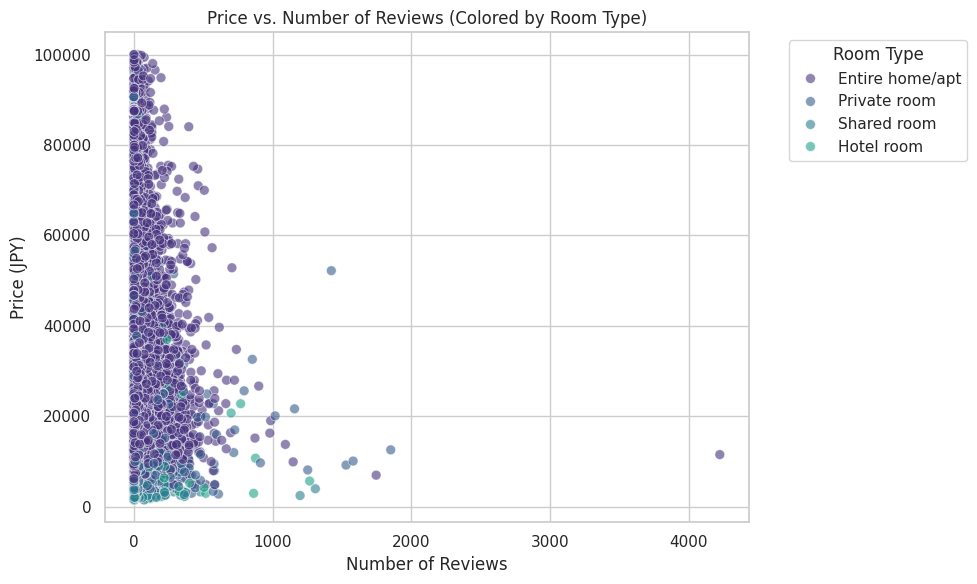

In [ ]:
# Scatterplot: 'price' vs 'number_of_reviews'
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='number_of_reviews',
    y='price',
    data=tokyo_airbnb_df_cleaned,
    alpha=0.6,
    hue='room_type', # Add hue for better insights
    s=50 # Adjust point size
)
plt.title('Price vs. Number of Reviews (Colored by Room Type)')
plt.xlabel('Number of Reviews')
plt.ylabel('Price (JPY)')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


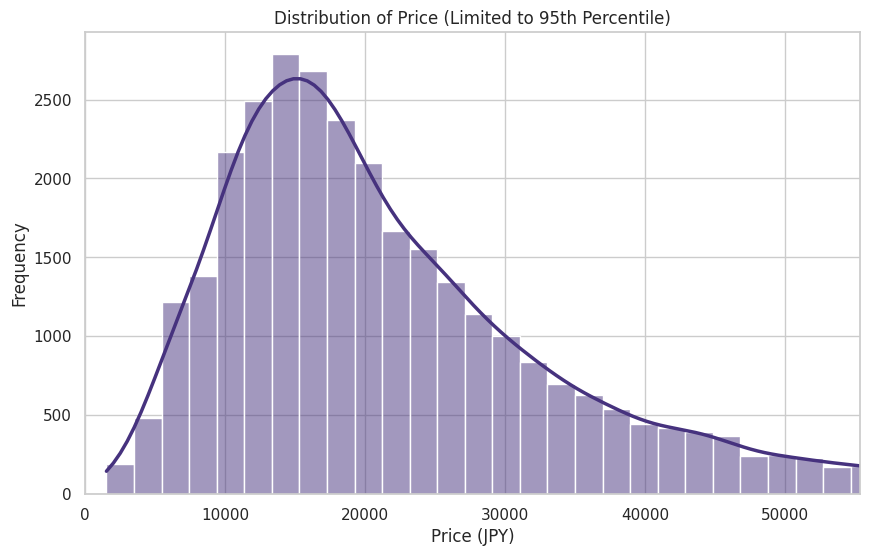

In [ ]:
# Histogram: Distribution of 'price' (limit x-axis to 95th percentile for clarity)
plt.figure(figsize=(10, 6))

# Calculate the 95th percentile of price
price_95th_percentile = tokyo_airbnb_df_cleaned['price'].quantile(0.95)

sns.histplot(
    tokyo_airbnb_df_cleaned['price'],
    bins=50,
    kde=True,
    line_kws={'linewidth': 2.5, 'color': 'red'}
)
plt.title('Distribution of Price (Limited to 95th Percentile)')
plt.xlabel('Price (JPY)')
plt.ylabel('Frequency')
plt.xlim(0, price_95th_percentile) # Set x-axis limit
plt.show()

/tmp/ipykernel_1810/4168313945.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='room_type', y='price', data=tokyo_airbnb_df_cleaned, ci=None)


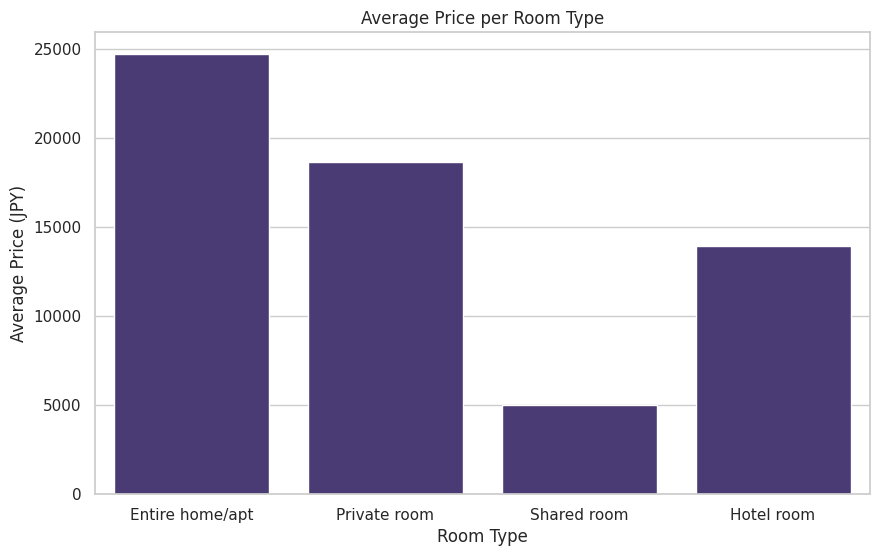

In [ ]:
# Barchart: Average 'price' per 'room_type'
plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price', data=tokyo_airbnb_df_cleaned, ci=None)
plt.title('Average Price per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price (JPY)')
plt.show()

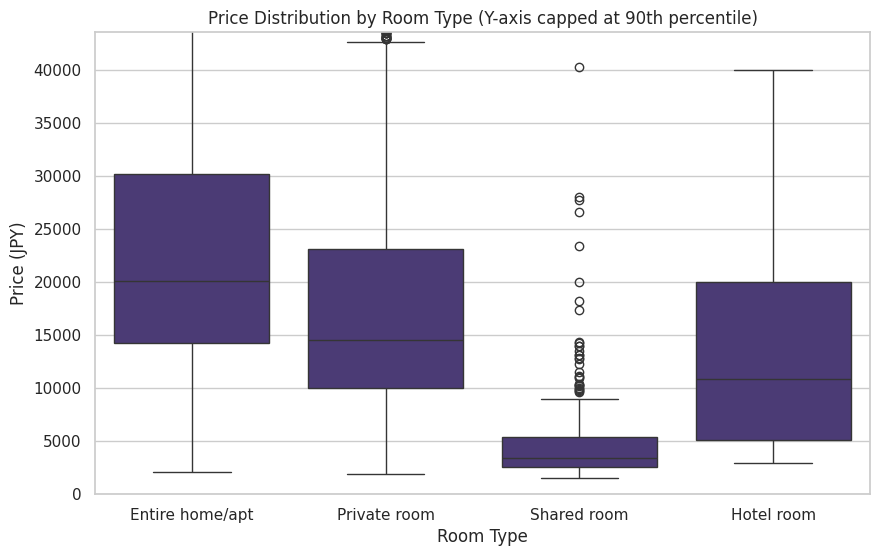

In [ ]:
# Boxplot: 'price' distributed by 'room_type' (limit y-axis to reduce outlier noise)
plt.figure(figsize=(10, 6))

# Calculate the 90th percentile of price for y-axis limit
price_90th_percentile = tokyo_airbnb_df_cleaned['price'].quantile(0.90)

sns.boxplot(x='room_type', y='price', data=tokyo_airbnb_df_cleaned)
plt.title('Price Distribution by Room Type (Y-axis capped at 90th percentile)')
plt.xlabel('Room Type')
plt.ylabel('Price (JPY)')
plt.ylim(0, price_90th_percentile) # Limit y-axis
plt.show()

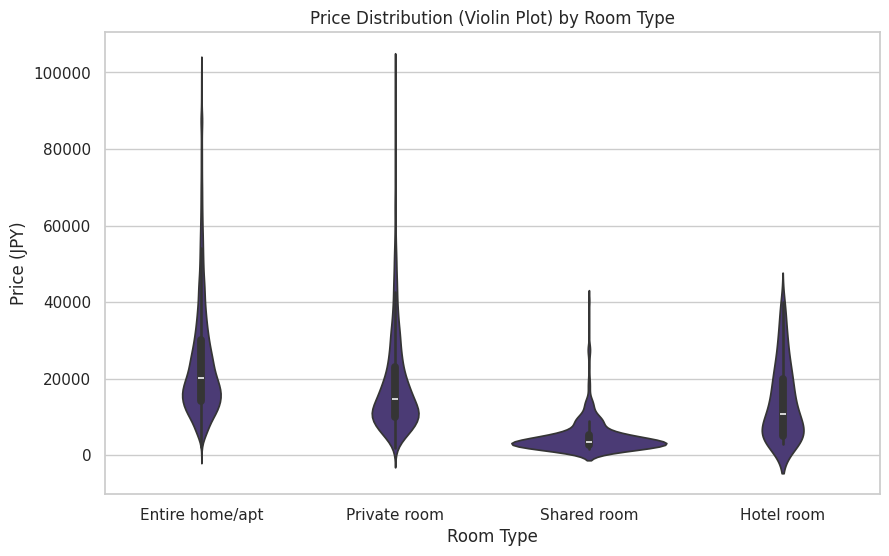

In [ ]:
# Violin plot: 'price' distributed by 'room_type'
plt.figure(figsize=(10, 6))
sns.violinplot(x='room_type', y='price', data=tokyo_airbnb_df_cleaned)
plt.title('Price Distribution (Violin Plot) by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (JPY)')
plt.show()

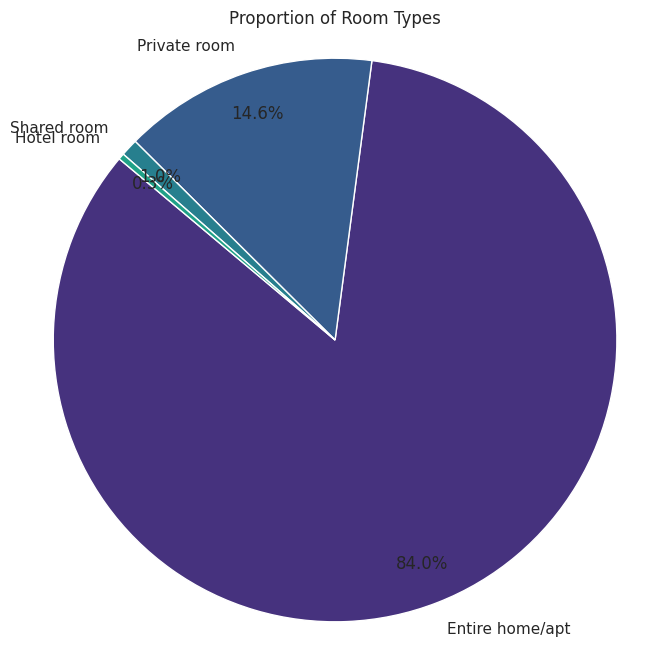

In [ ]:
# Piechart: Proportion of 'room_type'
plt.figure(figsize=(8, 8))
room_type_counts = tokyo_airbnb_df_cleaned['room_type'].value_counts()
plt.pie(
    room_type_counts,
    labels=room_type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85 # Distance of percentage labels from center
)
plt.title('Proportion of Room Types')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

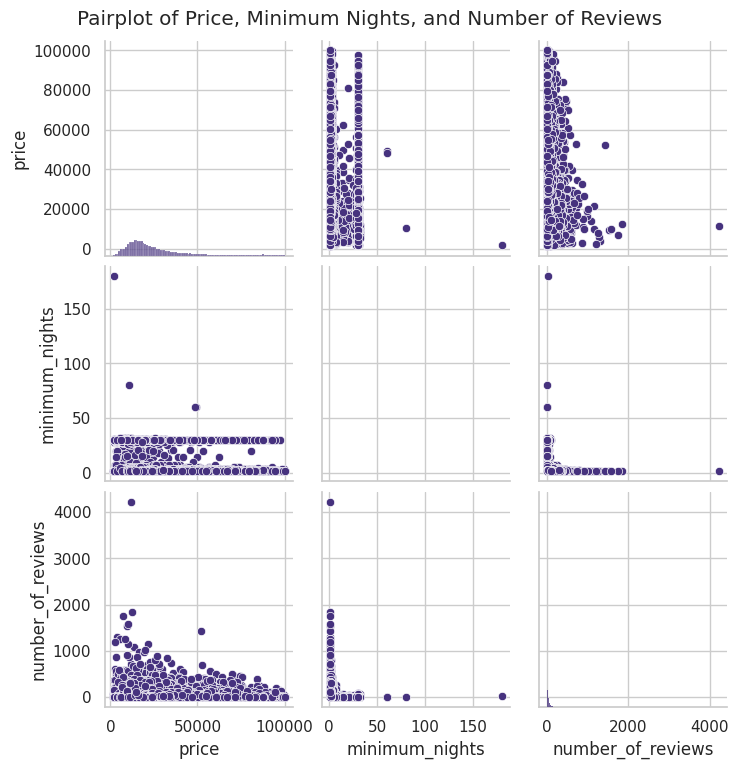

In [ ]:
# Pairplot: On a subset of ['price', 'minimum_nights', 'number_of_reviews']

# Ensure selected columns exist
pairplot_cols = ['price', 'minimum_nights', 'number_of_reviews']
pairplot_cols = [col for col in pairplot_cols if col in tokyo_airbnb_df_cleaned.columns]

# Create the pairplot
sns.pairplot(tokyo_airbnb_df_cleaned[pairplot_cols])
plt.suptitle('Pairplot of Price, Minimum Nights, and Number of Reviews', y=1.02) # Adjust title position
plt.show()

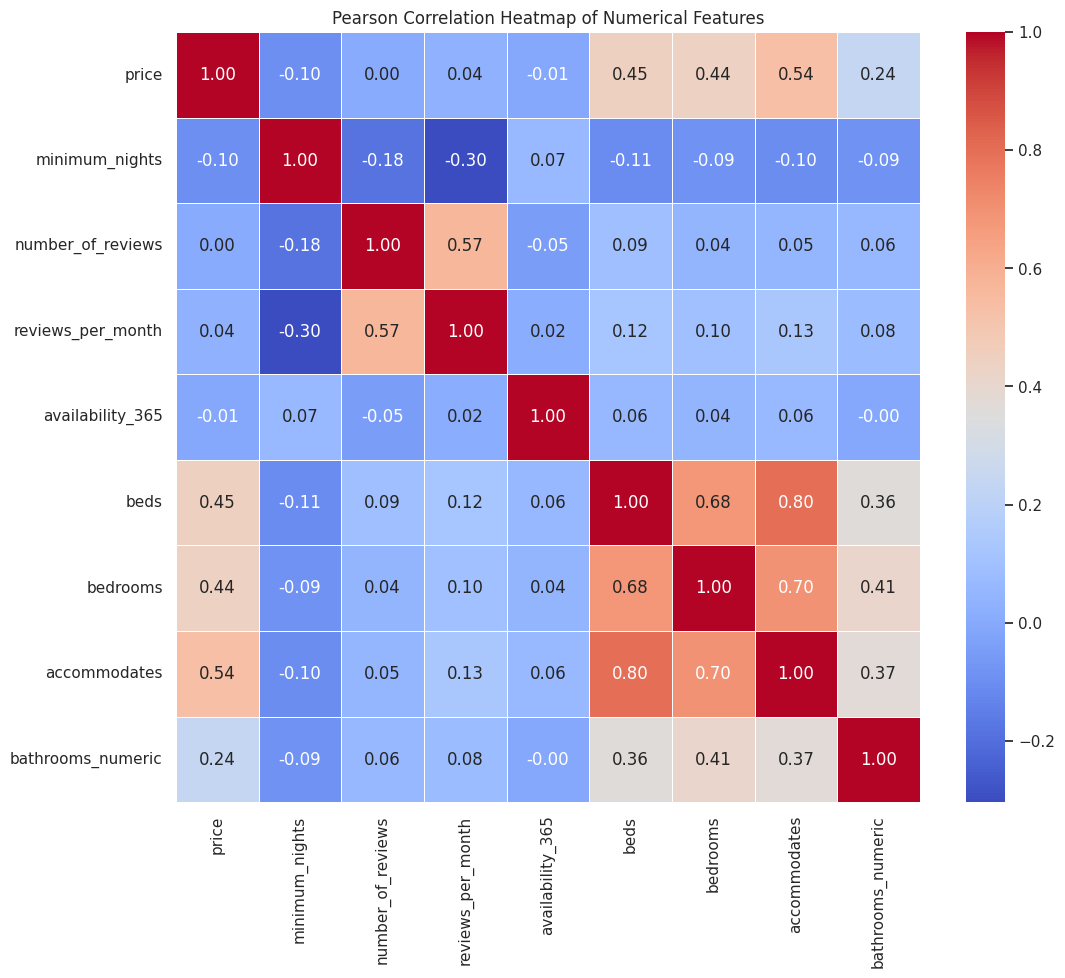

In [ ]:
# Heatmap: Using the Pearson correlation matrix
plt.figure(figsize=(12, 10))

# Recalculate Pearson correlation for the heatmap (using the df_corr from earlier)
pearson_corr = df_corr.corr(method='pearson')

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm', # Use a diverging colormap
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Pearson Correlation Heatmap of Numerical Features')
plt.show()

### 7. Index Analysis

* **Current Index:** By default, the `read_csv` function assigned a standard pandas `RangeIndex` (sequential integers starting from 0, up to the length of the dataset).
* **Index Meaningfulness:** A `RangeIndex` is functional for basic row iteration, but it lacks intrinsic meaning. It does not tell us anything about the specific data point.
* **Recommendation for Improvement:** The dataset contains an `id` column, which serves as the unique identifier for each specific Airbnb listing. Setting this column as the DataFrame's index (using `tokyo_airbnb_df.set_index('id')`) would be much more semantically correct, prevent duplicate listings more easily, and improve data retrieval performance when searching for specific properties.

### 8. Insights and Data Storytelling

The exploratory data analysis (EDA) of the Inside Airbnb Tokyo dataset reveals a highly optimized market tailored to the international tourist experience rather than standard local residential housing.

**The Story of Tokyo's Airbnb Market:**

1. **The Premium on Privacy (Room Types):** The market is overwhelmingly dominated by 'Entire home/apt' listings (over 84%). This indicates that tourists traveling to Japan strongly prefer private, independent spaces. Shared rooms are practically non-existent in this dataset, showing there is little demand for them outside of specialized hostel platforms.
2. **Transit-Driven Geography:** Supply is fiercely concentrated in major transit and entertainment hubs—specifically Shinjuku, Sumida, and Taito wards. These areas offer the best connectivity to the massive subway network and major attractions. The data proves that location and transit access dictate the Airbnb landscape in Tokyo.
3. **The Reality of Pricing:** The pricing structure is extremely right-skewed. While the statistical *Mean* is heavily inflated by a few luxury listings and hosts using absurd "placeholder" prices (up to 5.4 million JPY), the *Median* price of ~19,189 JPY provides a highly accurate and realistic benchmark for a standard nightly rate. Furthermore, the base of the market (~1,500 JPY) perfectly reflects Tokyo's famous ultra-budget accommodations, such as capsule hotels and internet cafes.
4. **The Long-Term Submarket:** There is a slight negative correlation between minimum nights and review frequency/price. This uncovers a secondary "hidden" market within the data: listings requiring long minimum stays are likely geared toward corporate housing, digital nomads, or students, operating on lower nightly rates and receiving far less turnover (and thus fewer reviews) than short-term tourist traps.

**Final Conclusion:**
To succeed in the Tokyo Airbnb market, a property must ideally be an entire apartment located within walking distance of a major ward's train station (like Shinjuku). The data clearly shows that deviations from this formula—such as offering shared rooms or operating in peripheral wards—result in significantly lower market share and visibility.